In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import yaml
from motor_imagery_inefficient_users import io, preprocess
from pathlib import Path

def find_project_root(marker="config.yaml") -> Path:
    """Walk up from the notebook's CWD until we find the marker file."""
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root (looked for '{marker}')")

project_root = find_project_root()

with open(project_root / "config.yaml") as f:
    config = yaml.safe_load(f)

In [ ]:
calibration_data_path = project_root / config["data_calibration"]
fs = config["fs"]
task_start_time_s = config["task_start_time_s"]
task_end_time_s = config["task_end_time_s"]
num_trials = config["num_trials"]
num_chans = config["num_chans"]


In [ ]:
# get participant ids inside the calibration folder
pids = sorted(io.get_participant_ids(data_path=calibration_data_path))

example_pid = pids[0]

# load participant data / continous eeg data
X_continuous = io.get_calibration_data_for_participant(
    calibration_data_path=calibration_data_path, participant_id=example_pid
)

# get epoched data for the duration of the task
X_epoched, y = preprocess.get_epoched_eeg_and_labels(
    X_continuous=X_continuous,
    num_chans=num_chans,
    num_trials=num_trials,
    task_start_time_s=task_start_time_s,
    task_end_time_s=task_end_time_s,
    fs=fs,
)

<h4> CSP

<h4> Covariance matrix for one epoch as an example

In [ ]:
epoch = np.array(X_epoched[0])
epoch_c = epoch - epoch.mean(axis=1, keepdims=True)
print(epoch_c.shape[0], epoch_c.shape[1])

16 1000


Covariance matrix shape: (16, 16)
Diagonal (channel variances):
 [116.8556 136.9736 134.5561 100.3675 111.657   85.7935  84.6853 103.0206
  95.2634  72.1008 107.0724  73.3802 102.4686 108.0807 112.7669  73.9628]


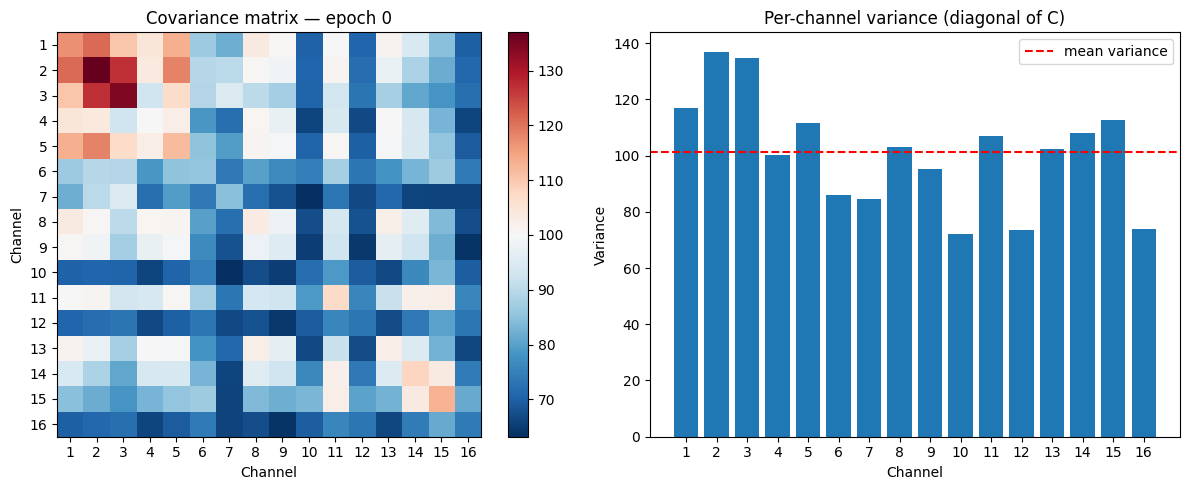

In [ ]:
C = (epoch_c @ epoch_c.T) / (epoch_c.shape[1] - 1)

print("Covariance matrix shape:", C.shape)
print("Diagonal (channel variances):\n", np.diag(C).round(4))

# visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(C, cmap="RdBu_r", aspect="auto")
axes[0].set_title("Covariance matrix — epoch 0")
axes[0].set_xticks(range(16))
axes[0].set_xticklabels(range(1, 17))
axes[0].set_yticks(range(16))
axes[0].set_yticklabels(range(1, 17))
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Channel")
plt.colorbar(im, ax=axes[0])

# also look at just the diagonal (per-channel variance)
axes[1].bar(range(16), np.diag(C))
axes[1].set_title("Per-channel variance (diagonal of C)")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Variance")
axes[1].set_xticks(range(16))
axes[1].set_xticklabels(range(1, 17))
axes[1].axhline(np.diag(C).mean(), color="red", linestyle="--", label="mean variance")
axes[1].legend()

plt.tight_layout()
plt.show()


<h4> Compute covariance matrices across all trials belonging to their respective classes

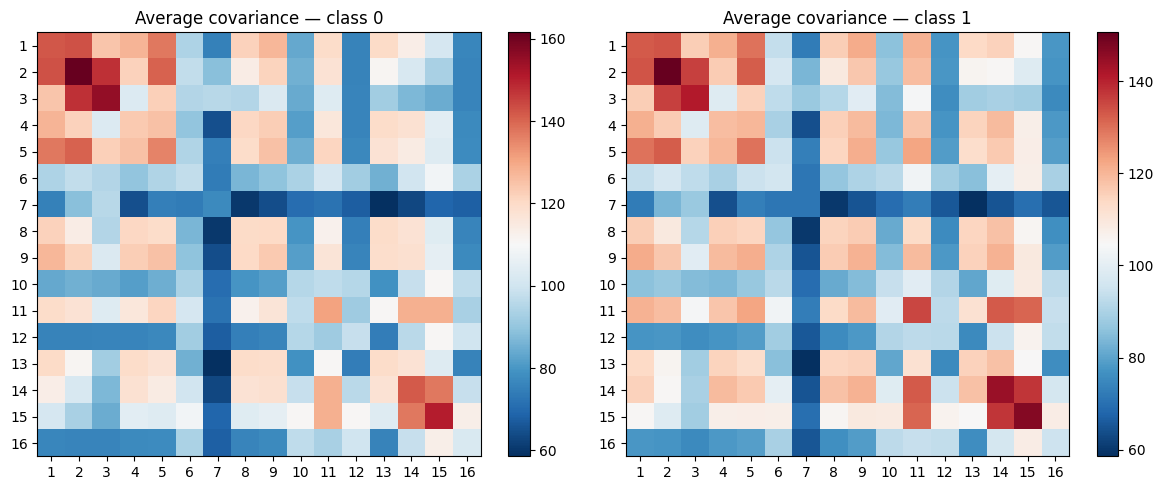

In [ ]:
C_per_class = {}

for cls in [0, 1]:
    trials = X_epoched[y == cls]  # shape: (n_trials_cls, 16, 2000)
    covs = []
    for trial in trials:
        trial_c = trial - trial.mean(axis=1, keepdims=True)
        C = (trial_c @ trial_c.T) / (trial_c.shape[1] - 1)
        covs.append(C)
    C_per_class[cls] = np.mean(covs, axis=0)  # average over trials

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for cls in [0, 1]:
    im = axes[cls].imshow(C_per_class[cls], cmap="RdBu_r", aspect="auto")
    axes[cls].set_title(f"Average covariance — class {cls}")
    axes[cls].set_xticks(range(16))
    axes[cls].set_xticklabels(range(1, 17))
    axes[cls].set_yticks(range(16))
    axes[cls].set_yticklabels(range(1, 17))
    plt.colorbar(im, ax=axes[cls])

plt.tight_layout()
plt.show()

<h4>Calculate difference between covariance matrices:</h4>

<ul style="font-size: 1.1em;">
  <li>This tells us how much channel activity changes between classes, the hot values are as useful as the cool ones.</li>
  <li>For channel 3, variance in class 0 was higher than in class 1, and for channel 11 the opposite was the case.</li>
  <li>We can also look at covariance of channel pairs and how it changes here. For instance, covariance of channel 15 with 11 was higher for class 1.</li>
</ul>

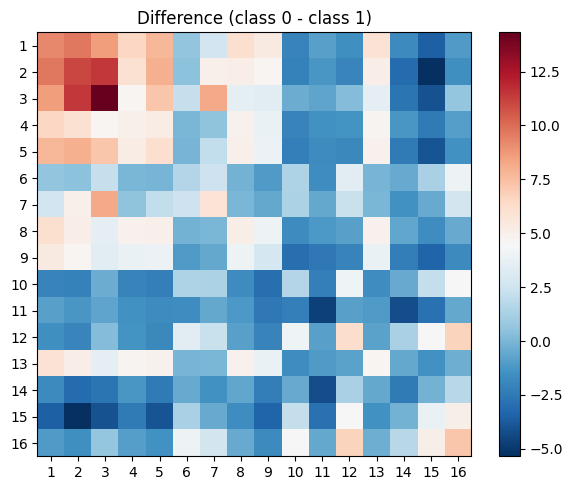

In [ ]:
diff = C_per_class[0] - C_per_class[1]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(diff, cmap="RdBu_r", aspect="auto")
ax.set_title("Difference (class 0 - class 1)")
ax.set_xticks(range(16))
ax.set_xticklabels(range(1, 17))
ax.set_yticks(range(16))
ax.set_yticklabels(range(1, 17))
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

<h4>Thinking of CSP as a generalized eigen value problem</h4>

To see how this is (roughly) arrived at, look at the pdf inside the `understand_CSP` folder.

$\bar{C}_0 \mathbf{w} = \lambda (\bar{C}_0 + \bar{C}_1) \mathbf{w}$

To first find w, we will use `scipy`


In [ ]:
from scipy.linalg import eigh

# A = C0, B = C0 + C1
A = C_per_class[0]
B = C_per_class[0] + C_per_class[1]



<h4>W and its dimensions</h4>

Solving this problem as done below gives a 16 x 16 dimensional vector (based on number of channels). This returns a $Wn*n$ matrix where n = number of channels. Consequently, we know that:
 $$\lambda = \bar{C}_0 \mathbf{w} /  (\bar{C}_0 + \bar{C}_1) \mathbf{w}$$

Meaning:
1. Each $\mathbf{w}_i^{(n \times 1)}$ corresponds to one $\lambda_i$
2. When the value for $\lambda_i$ is close to 0, variance of class 1 is very high. And when values of $\lambda_i$ are close to 1, variance of class 0 is very high.

The idea here is that we will only pick the $w^is$ where we get lambda close to 0 or close to 1 and ignore the other $w^is$. This is whats used to find out the $var(w^T.X)$ which is ultimately fed to the classifier.

In [ ]:
# solve generalized eigenvalue problem
# returns eigenvalues sorted ascending and eigenvectors
eigenvalues, eigenvectors = eigh(A, B)

print("Eigenvalues:", eigenvalues.round(4))
print("Eigenvectors shape:", eigenvectors.shape)  # should be (16, 16)

Eigenvalues: [0.3689 0.4435 0.4486 0.466  0.4711 0.4825 0.4865 0.5078 0.5172 0.5251
 0.5324 0.5501 0.5612 0.5621 0.5872 0.6452]
Eigenvectors shape: (16, 16)


In [ ]:
m = 3

# first m columns (lambda near 0, maximally class 1)
# last m columns (lambda near 1, maximally class 0)
W = np.concatenate([eigenvectors[:, :m], eigenvectors[:, -m:]], axis=1)

print("W shape:", W.shape)  # should be (16, 6)

W shape: (16, 6)
